## XGBoost Classification - Loan Approval Prediction

In [1]:
## Step 0: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
)
from xgboost import XGBClassifier, plot_importance

In [3]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [4]:
# Create folders for outputs
os.makedirs("plots", exist_ok = True)
os.makedirs("model", exist_ok = True)

About the Dataset: 

The Loan Prediction Dataset contains ~614 loan application records with 12 features. A bank wants to automate the loan eligibility process based on customer details provided while filling the online application form.

Features: 
- Loan_ID – Unique loan identifier (will be dropped) 
- Gender – Male / Female 
- Married – Applicant married (Y/N) 
- Dependents – Number of dependents (0, 1, 2, 3+) 
- Education – Graduate / Not Graduate 
- Self_Employed – Self-employed (Y/N) 
- ApplicantIncome – Applicant's monthly income 
- CoapplicantIncome – Co-applicant's monthly income 
- LoanAmount – Loan amount (in thousands) 
- Loan_Amount_Term – Term of loan (in months) 
- Credit_History – Credit history meets guidelines (1/0) 
- Property_Area – Urban / Semiurban / Rural 
- Loan_Status – Loan approved (Y/N) ← TARGET 


In [5]:
## Step 1: Load the Dataset
df = pd.read_csv("loan_data/train_u6lujuX_CVtuZ9i.csv")

In [6]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
## Step 2: Exploratory Data Analysis (EDA)
# Basic Statistics
print("Descriptive Statistics:\n")
df.describe()

Descriptive Statistics:



,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [9]:
# Missing values
print("\nMissing values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0])
# print(missing)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per Column:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

Total missing values: 149


In [10]:
# Target distribution 
print(f"\nTarget Distribution (Loan_Status):")
print(df["Loan_Status"].value_counts())
print(df["Loan_Status"].value_counts(normalize = True) * 100)


Target Distribution (Loan_Status):
Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [11]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


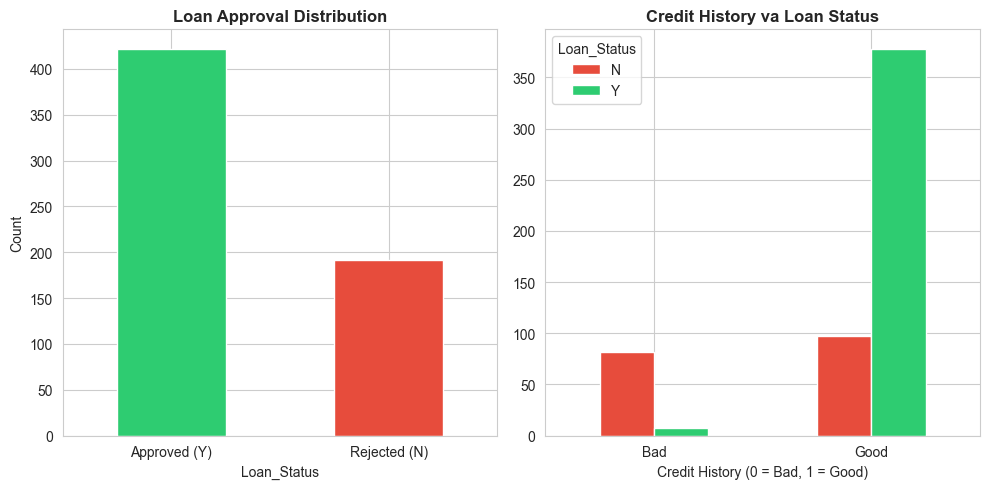

In [12]:
# Visualize target distribution

fig, axes = plt.subplots(1, 2, figsize = (10, 5))
df["Loan_Status"].value_counts().plot(kind = "bar", ax = axes[0], color = ["#2ecc71", "#e74c3c"])
axes[0].set_title("Loan Approval Distribution", fontweight = "bold")
axes[0].set_xticklabels(["Approved (Y)", "Rejected (N)"], rotation = 0)
axes[0].set_ylabel("Count")


# Credit history vs loan status (important insight!)
pd.crosstab(df["Credit_History"], df["Loan_Status"]).plot(kind = "bar", ax = axes[1], color = ["#e74c3c", "#2ecc71"])
axes[1].set_title("Credit History va Loan Status", fontweight = "bold")
axes[1].set_xlabel("Credit History (0 = Bad, 1 = Good)")
axes[1].set_xticklabels(["Bad", "Good"], rotation = 0)
plt.tight_layout()

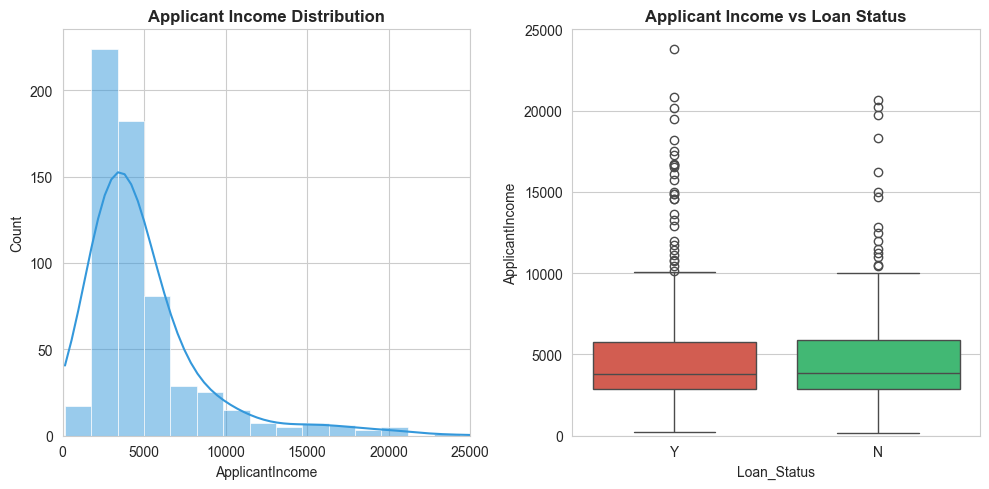

In [13]:
# Income Distribution
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
sns.histplot(df["ApplicantIncome"], bins = 50, kde = True, ax = axes[0], color = "#3498db")
axes[0].set_title("Applicant Income Distribution", fontweight = "bold")
axes[0].set_xlim(0, 25000)

sns.boxplot(x = "Loan_Status", y = "ApplicantIncome", data = df, ax = axes[1], palette = ["#e74c3c", "#2ecc71"])
axes[1].set_title("Applicant Income vs Loan Status", fontweight = "bold")
axes[1].set_ylim(0, 25000)
plt.tight_layout()

In [14]:
## Step 3: Data Preprocessing - Handle Missing Values

In [15]:
# Drop Loan_ID - it's just an identifier, not useful for prediction
df = df.drop("Loan_ID", axis = 1)

Strategy:
- Categorical features -> Fill with Mode (Most frequent value)
- Numerical features -> Fill with Median (robust to outliers)

In [16]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
numerical_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

In [17]:
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled {col} missing values with mode: {mode_val}")

    
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median: {median_val}")

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Filled Gender missing values with mode: Male
Filled Married missing values with mode: Yes
Filled Dependents missing values with mode: 0
Filled Self_Employed missing values with mode: No
Filled LoanAmount missing values with median: 128.0
Filled Loan_Amount_Term missing values with median: 360.0
Filled Credit_History missing values with median: 1.0
Remaining missing values: 0


In [18]:
## Step 4: Feature Engineering

Creating meaningful new features often improves model performance more than hyperparameter tuning. Let's create features that capture financial relationships:

In [19]:
# Total household income (applicant + co-applicant)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
print("Created 'TotalIncome' = ApplicantIncome + CoapplicantIncome")

Created 'TotalIncome' = ApplicantIncome + CoapplicantIncome


In [20]:
# EMI (Equated monthly installment) - a proxy
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
print("Created 'EMI' = LoanAmount / Loan_Amount_Term")

Created 'EMI' = LoanAmount / Loan_Amount_Term


In [21]:
# Balance income after paying EMI
df['BalanceIncome'] = df['TotalIncome'] - (df['EMI'] * 1000)
print("Created 'BalanceIncome' = TotalIncome - (EMI * 1000)")

Created 'BalanceIncome' = TotalIncome - (EMI * 1000)


In [22]:
# Log transform skewed numerical features (makes distribution more normal)
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])
df['TotalIncome_log'] = np.log1p(df['TotalIncome'])
print("Applied log transform to skewed features")

Applied log transform to skewed features


In [23]:
## Step 5: Encoding Categorical Variables
# Handle 3+ in Dependent column
df['Dependents'] = df['Dependents'].replace("3+", 3)
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].median()).astype(int)

In [24]:
# Label encoding for binary/ordinal categorical features
label_encoders = {}
cat_cols_to_encode = [
    "Gender", "Married", "Education",
    "Self_Employed", "Property_Area", "Loan_Status"
]

for col in cat_cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col:18s} -> {mapping}")

print(f"\nEncoded dataframe shape: {df.shape}")
print(f"\nDtypes after encoding: \n{df.dtypes}")

Gender             -> {'Female': 0, 'Male': 1}
Married            -> {'No': 0, 'Yes': 1}
Education          -> {'Graduate': 0, 'Not Graduate': 1}
Self_Employed      -> {'No': 0, 'Yes': 1}
Property_Area      -> {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
Loan_Status        -> {'N': 0, 'Y': 1}

Encoded dataframe shape: (614, 17)

Dtypes after encoding: 
Gender                 int32
Married                int32
Dependents             int32
Education              int32
Self_Employed          int32
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int32
Loan_Status            int32
TotalIncome          float64
EMI                  float64
BalanceIncome        float64
LoanAmount_log       float64
TotalIncome_log      float64
dtype: object


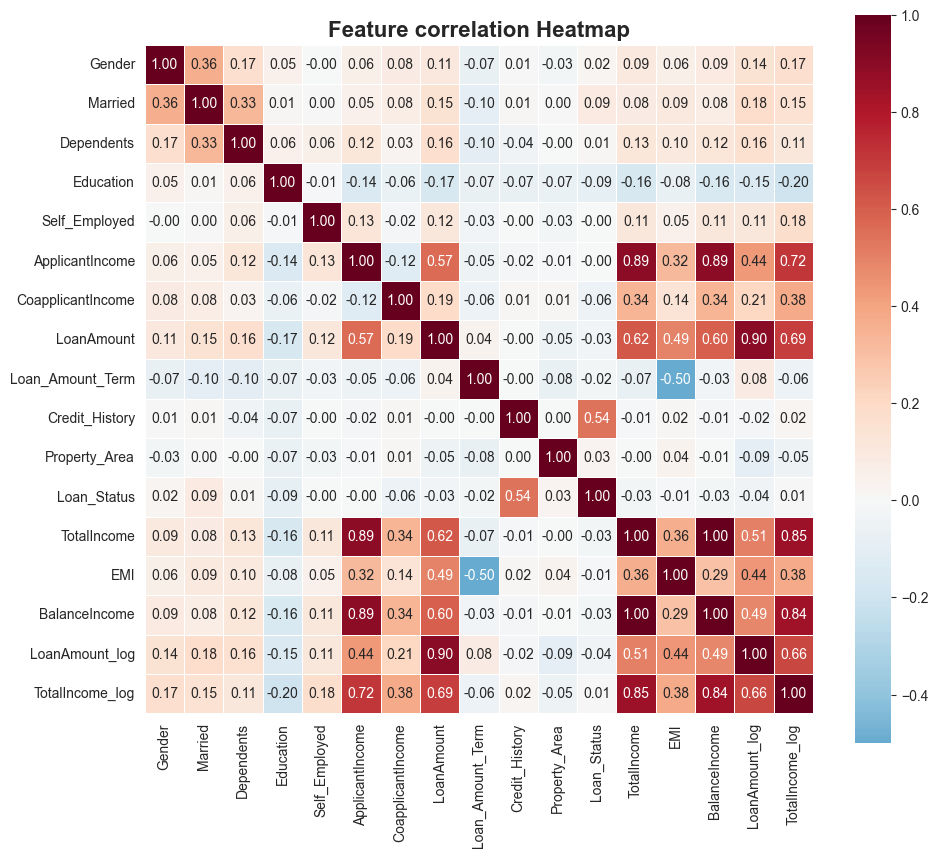

In [25]:
## Step 6: Correlation Analysis (post-encoding)
plt.figure(figsize = (10, 10))
sns.heatmap(df.corr(), annot = True, fmt = ".2f", cmap = "RdBu_r", center = 0, linewidth = 0.5, square = True, cbar_kws = {"shrink": 0.8})
plt.title("Feature correlation Heatmap", fontsize = 16, fontweight = "bold")
plt.tight_layout()

In [26]:
## Step 7: Train-Test Split
X = df.drop("Loan_Status", axis = 1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training set : {X_train.shape[0]} samples, {X_train.shape[1]} feayures")
print(f" Test set     : {X_test.shape[0]} samples")
print(f"\n Train target distribution:\n{y_train.value_counts()}")

 Training set : 491 samples, 16 feayures
 Test set     : 123 samples

 Train target distribution:
Loan_Status
1    337
0    154
Name: count, dtype: int64


In [27]:
## Step 8: Baseline XGBoost Model

Key XGBoost Hyperparameters:
- n_estimators : Number of boosting rounds (trees) 
- max_depth : Maximum depth of each tree 
- learning_rate : Step-size shrinkage (η) — lower = more robust 
- subsample : Fraction of training samples used per tree 
- colsample_bytree : Fraction of features used per tree 
- gamma : Minimum loss reduction for further partition 
- reg_alpha : L1 regularization on leaf weights 
- reg_lambda : L2 regularization on leaf weights

In [28]:
xgb_baseline = XGBClassifier(
    n_estimators = 100,
    max_depth = 4,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric = "logloss",
    use_label_encoder = False,
    random_state = 42,
)

xgb_baseline.fit(X_train, y_train)
y_pred_baseline = xgb_baseline.predict(X_test)
y_prob_baseline = xgb_baseline.predict_proba(X_test)[:, 1]   

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)                
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)      

print(f"\n Baseline Accuracy : {baseline_acc:.4f}  ({baseline_acc * 100:.2f}%)")
print(f" Baseline F1 Score : {baseline_f1:.4f}")              
print(f" Baseline ROC-AUC  : {baseline_roc_auc:.4f}")         

cv_scores = cross_val_score(xgb_baseline, X, y, cv = 5, scoring = "accuracy")
print(f" 5-fold CV Accuracy       : {cv_scores.mean():.4f} ± {cv_scores.std(): .4f}")


 Baseline Accuracy : 0.8130  (81.30%)
 Baseline F1 Score : 0.8686
 Baseline ROC-AUC  : 0.8071
 5-fold CV Accuracy       : 0.7753 ±  0.0165


In [29]:
## Step 9: Hyperparameter Tuning (GridsearchCV)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator = XGBClassifier(
        eval_metric = "logloss", use_label_encoder = False, random_state = 42
    ),
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1,
    verbose = 0,
)

grid_search.fit(X_train, y_train)

print(f"\n Best Parameters Found:")
for k, v in grid_search.best_params_.items():
    print(f" {k:22s} : {v}")
print(f"\n Best CV Accuracy: {grid_search.best_score_:.4f}")


 Best Parameters Found:
 colsample_bytree       : 0.8
 learning_rate          : 0.01
 max_depth              : 4
 n_estimators           : 100
 subsample              : 0.7

 Best CV Accuracy: 0.7984


In [30]:
## Step 10: Evaluate the Tuned Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [31]:
# Accuracy, F1, ROC-AUC
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\n Test Accuracy  : {acc:.4f}  ({acc * 100:.2f}%)")
print(f" F1 Score        : {f1:.4f}")
print(f" ROC-AUC Score   : {roc_auc:.4f}")


 Test Accuracy  : 0.8537  (85.37%)
 F1 Score        : 0.9032
 ROC-AUC Score   : 0.8201


In [32]:
# Classification Report
print(f"\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names = ["Rejected (N)", "Approved (Y)"]))


 Classification Report:

              precision    recall  f1-score   support

Rejected (N)       0.95      0.55      0.70        38
Approved (Y)       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



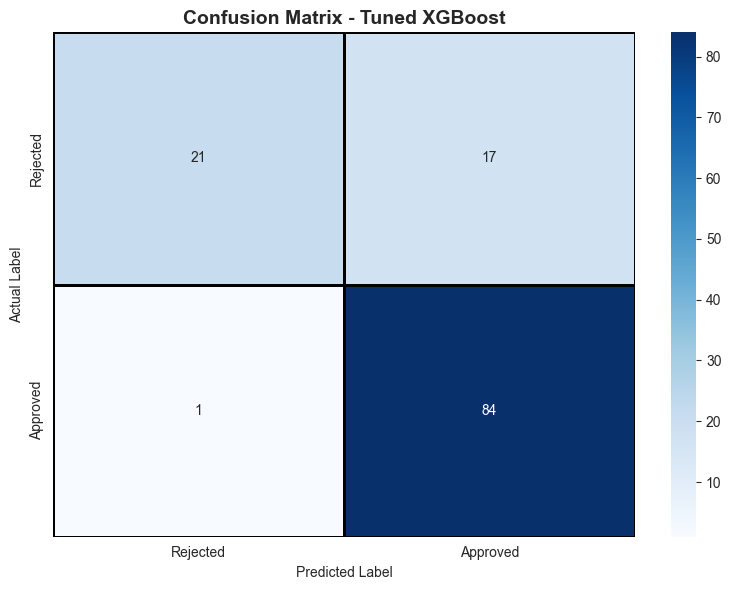

In [33]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
           xticklabels=["Rejected", "Approved"],
           yticklabels=["Rejected", "Approved"],
           linewidths=1, linecolor="black")
plt.title("Confusion Matrix - Tuned XGBoost", fontsize = 14, fontweight = "bold")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

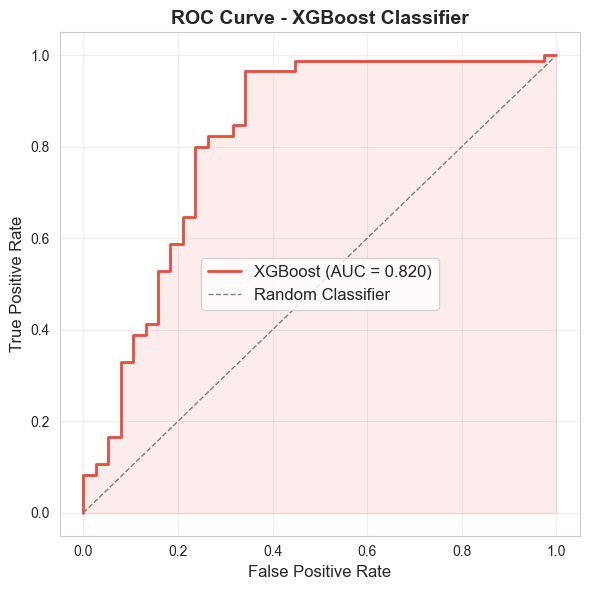

In [34]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize = (6, 6))
plt.plot(fpr, tpr, color = "#e74c3c", lw = 2, label = f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color = "gray", linestyle = "--", lw = 1, label = "Random Classifier")
plt.fill_between(fpr, tpr, alpha = 0.1, color = "#e74c3c")
plt.xlabel("False Positive Rate", fontsize = 12)
plt.ylabel("True Positive Rate", fontsize = 12)
plt.title("ROC Curve - XGBoost Classifier", fontsize = 14, fontweight = "bold")
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.tight_layout()

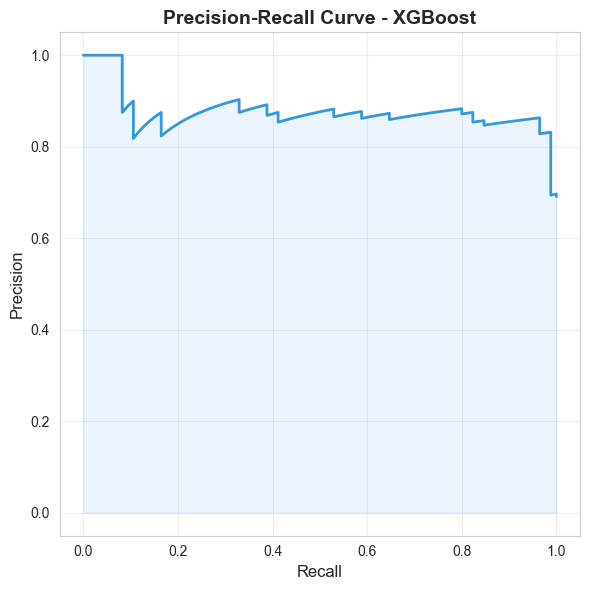

In [35]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize = (6, 6))
plt.plot(recall, precision, color = "#3498db", lw = 2)
plt.fill_between(recall, precision, alpha = 0.1, color = "#3498db")
plt.xlabel("Recall", fontsize = 12)
plt.ylabel("Precision", fontsize = 12)
plt.title("Precision-Recall Curve - XGBoost", fontsize = 14, fontweight = "bold")
plt.grid(True, alpha = 0.3)
plt.tight_layout()

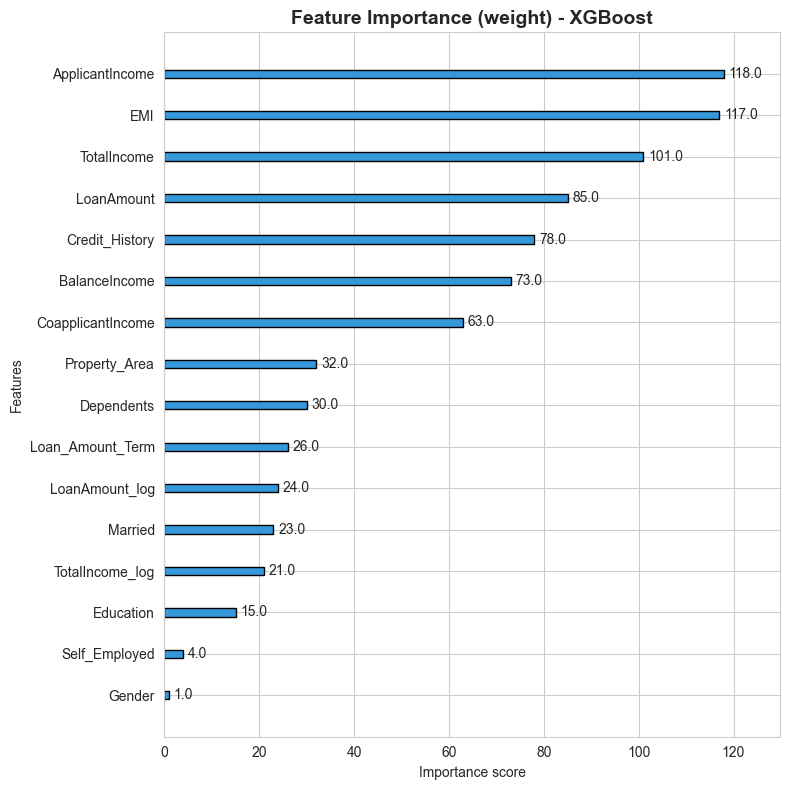

In [36]:
## Step 11:
fig, ax = plt.subplots(figsize = (8, 8 ))
plot_importance(best_model, ax = ax, importance_type="weight", color = "#3498db", edgecolor = "black")
ax.set_title("Feature Importance (weight) - XGBoost", fontsize = 14, fontweight = "bold")
plt.tight_layout()

In [37]:
importances = best_model.feature_importances_
feature_ranking = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop = True)

print("\n Feature Ranking")
for i, row in feature_ranking.iterrows():
    bar = "█" * int(row["Importance"] * 80)
    print(f" {i + 1:2d}. {row['Feature']:20s} {row['Importance']:.4f} {bar}")


 Feature Ranking
  1. Credit_History       0.4496 ███████████████████████████████████
  2. BalanceIncome        0.0474 ███
  3. Married              0.0454 ███
  4. EMI                  0.0424 ███
  5. Property_Area        0.0417 ███
  6. TotalIncome_log      0.0415 ███
  7. TotalIncome          0.0413 ███
  8. CoapplicantIncome    0.0412 ███
  9. Education            0.0391 ███
 10. ApplicantIncome      0.0376 ███
 11. LoanAmount           0.0361 ██
 12. Self_Employed        0.0360 ██
 13. Dependents           0.0353 ██
 14. Loan_Amount_Term     0.0339 ██
 15. LoanAmount_log       0.0251 ██
 16. Gender               0.0064 


In [38]:
## Step 12: Save the Model
joblib.dump(best_model, "model/xgboost_loan_approval_model.pkl")
joblib.dump(label_encoders, "model/label_encoders.pkl")

print("Model Saved -> model/xgboost_loan_approval_model.pkl")
print("Encoders saved -> model/label_encoders.pkl")

Model Saved -> model/xgboost_loan_approval_model.pkl
Encoders saved -> model/label_encoders.pkl


In [39]:
## Step 13: Inference Demo - Predict on a new loan Application
loaded_model = joblib.load("model/xgboost_loan_approval_model.pkl")

# Example new applicant (already preprocessed as the model expects)
new_applicant = pd.DataFrame({
    "Gender": [1],            # 1 = Male
    "Married": [1],           # 1 = Yes
    "Dependents": [0],        # 0 dependents
    "Education": [0],         # 0 = Graduate
    "Self_Employed": [0],     # 0 = No
    "ApplicantIncome": [5000],
    "CoapplicantIncome": [2000],
    "LoanAmount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1.0],
    "Property_Area": [2],
    "TotalIncome": [7000],
    "EMI": [150 / 360],
    "BalanceIncome": [7000 - (150 / 360) * 1000],
    "LoanAmount_log": [np.log1p(150)],
    "TotalIncome_log": [np.log1p(7000)],
    
})

new_applicant = new_applicant[loaded_model.get_booster().feature_names]
# Reorder columns to match training data
new_applicant = new_applicant[X.columns]

prediction = loaded_model.predict(new_applicant)
probability = loaded_model.predict_proba(new_applicant)

print(f"\n Applicant Profile  : Graduate, married Male, Income = 5000, Loan = 150k")
print(f" Credit History     : Good (1.0)")
print(f"\n Prediction         : {'Loan Approved' if prediction[0] == 1 else 'Loan Rejected'}")
print(f" Confidence         : {max(probability[0]) * 100:.2f}")
print(f" Probabilities      : Rejected = {probability[0][0]:.4f}, Approved = {probability[0][1]:.4f}")


 Applicant Profile  : Graduate, married Male, Income = 5000, Loan = 150k
 Credit History     : Good (1.0)

 Prediction         : Loan Approved
 Confidence         : 75.17
 Probabilities      : Rejected = 0.2483, Approved = 0.7517


In [40]:
## Summary
print(" Project Complete - Summary")
print(f"""
    Dataset : Loan Prediction Dataset — 614 applications, 12 features 
    Algorithm : XGBoost (Extreme Gradient Boosting) 
    Baseline Acc. : {baseline_acc * 100:.2f}% 
    Tuned Acc. : {acc * 100:.2f}% 
    ROC-AUC : {roc_auc:.4f} 
    F1 Score : {f1:.4f} 
    Best Params : {grid_search.best_params_} 
    Files Generated:
        model/xgboost_loan_approval_model.pkl 
        model/label_encoders.pkl
""")

 Project Complete - Summary

    Dataset : Loan Prediction Dataset — 614 applications, 12 features 
    Algorithm : XGBoost (Extreme Gradient Boosting) 
    Baseline Acc. : 81.30% 
    Tuned Acc. : 85.37% 
    ROC-AUC : 0.8201 
    F1 Score : 0.9032 
    Best Params : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.7} 
    Files Generated:
        model/xgboost_loan_approval_model.pkl 
        model/label_encoders.pkl

